# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
importlib.reload(up)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>

### Get model data and plot together

In [7]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/simulate_2024_human_azimuth_spotlight_experiment_alt_ears").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

model_name_dict = {
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
                   "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
                   "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
                   "word_task_deep_fc_1024_v08": "Deeper Architecture",
                   "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
                   "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials"
                  }


gend_map = {True:'same', False:'diff'}
for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
        continue
    if 'modulated' in path.stem:
        continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = model_name_dict[path.parent.stem]

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    if 'white_noise' in path.as_posix():
        df['distractor_type'] = 'white_noise'
    elif 'texture' in path.as_posix():
        df['distractor_type'] = 'texture'
    else:
        df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)


In [8]:
results

,accuracy,confusions,preds,true_word_int,stim_ix_list,model,word,distractor_word,sex_cond,target_word,...,snr,target_azim,target_elev,distractor_azim,distractor_elev,room_ix,room_type,n_distractors,test_set,distractor_type
0,1,0,0,0,0,50% co-located GB v08 4M,about,"[present, police]",same,about,...,0,0,0,0,0,0,speech_distractor_mitb46,1,all_stim,speech
1,0,0,105,1,1,50% co-located GB v08 4M,above,"[search, later]",same,above,...,0,0,0,0,0,0,speech_distractor_mitb46,1,all_stim,speech
2,0,0,587,2,2,50% co-located GB v08 4M,access,"[regular, which]",same,access,...,0,0,0,0,0,0,speech_distractor_mitb46,1,all_stim,speech
3,1,0,4,4,3,50% co-located GB v08 4M,across,"[course, country]",same,across,...,0,0,0,0,0,0,speech_distractor_mitb46,1,all_stim,speech
4,1,0,5,5,4,50% co-located GB v08 4M,action,"[believe, found]",same,action,...,0,0,0,0,0,0,speech_distractor_mitb46,1,all_stim,speech
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,0,0,753,791,1947,50% co-located GB v08 4M,writing,"[early, version]",different,writing,...,0,-90,0,-90,0,0,speech_distractor_mitb46,1,all_stim,speech
1948,1,0,792,792,1948,50% co-located GB v08 4M,written,"[group, married]",different,written,...,0,-90,0,-90,0,0,speech_distractor_mitb46,1,all_stim,speech
1949,0,0,42,793,1949,50% co-located GB v08 4M,wrote,"[seven, twenty]",different,wrote,...,0,-90,0,-90,0,0,speech_distractor_mitb46,1,all_stim,speech
1950,1,0,795,795,1950,50% co-located GB v08 4M,yellow,"[state, event]",different,yellow,...,0,-90,0,-90,0,0,speech_distractor_mitb46,1,all_stim,speech


In [62]:
# # Path to results 
# # output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# # match human pilot conditions
# # model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_azimuth_spotlight_experiment_anechoic_human_stim/").glob("*/*.csv"))
# stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

# word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
# ix_to_word = {v:k for k,v in word_class_map.items()}

# remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

# results_dfs = []

# model_name_dict = {
#                    'word_task_v08_control_no_attn': 'Baseline CNN',
#                    "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
#                    "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
#                    "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
#                    "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
#                    "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
#                    "word_task_deep_fc_1024_v08": "Deeper Architecture",
#                    "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
#                    "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
#                    "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials",
#                    "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "learned no cue"
#                   }


# gend_map = {True:'same', False:'diff'}
# for path in output_paths:
#     # if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
#     #     continue

#     # res_dict = pickle.load(open(path, 'rb'))
#     try:
#         df = pd.read_csv(path)
#         df = pd.merge(df,
#                             manifests[cols_to_merge],
#                                         left_on='stim_name', right_on='stim_name', how='left')
#         df['response'] = df['pred_word_int'].replace(ix_to_word)
#         # df['confusions'] = (df.response == df.distractor_word).astype('int')
#         # df['accuracy'] = (df.response == df.word).astype('int')


#         # add adjusted accuracy and confusions 
#         pred_words = df.response.values
#         target_words = df.word.values
#         target_transcripts = df.target_transcripts.values
#         distractor_words = df.distractor_word.values
#         distractor_transcripts = df.distractor_transcripts.values


#         adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
#                                     if not isinstance(target_transcript, float) else np.nan
#                                     for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
#                                     ])

#         adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
#                                     if not (isinstance(distractor_transcript, float)) else np.nan
#                                     for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
#                                     ])

#         df['accuracy'] = adjusted_acc
#         df['confusions'] = adjusted_confs

#         df['target_azim'] = int(re.search('target_azim_(-?\d+)', path.stem).group(0).strip('target_azim_'))
#         df['distractor_azim'] = int(re.search('distractor_azim_(-?\d+)', path.stem).group(0).strip('distractor_azim_'))
#         df['target_azim'] = df['target_azim'].apply(remap_azim)
#         df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        
        
#         # df.rename(columns={"results": "accuracy"}, inplace=True)
#         df['model'] = model_name_dict[path.stem.split('_target')[0]]
#         results_dfs.append(df)
#     except Exception as e:
#         print(e)
#         print(path)
#         continue


# results = pd.concat(results_dfs)


In [9]:
results.model.unique()

array(['50% co-located GB v08 4M'], dtype=object)

In [64]:
# grouped_model_results = results.groupby(['model', 'target_azim', 'distractor_azim','sex_cond', 'snr', ]).agg({'accuracy':['mean', 'sem'],
#                                                                                                                      'confusions':['mean', 'sem']}).reset_index()
# # flatten multiindex
# grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# # remove trailing underscore
# grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]

# grouped_model_results['dist_azim_delta'] = grouped_model_results['distractor_azim'] - grouped_model_results['target_azim']
# grouped_model_results.head()

In [10]:
## Add distractor azim delta to model results 
results['dist_azim_delta'] = results['distractor_azim'] - results['target_azim']


In [11]:
results.columns

Index(['accuracy', 'confusions', 'preds', 'true_word_int', 'stim_ix_list',
       'model', 'word', 'distractor_word', 'sex_cond', 'target_word',
       'pred_word', 'correct', 'str_confusions', 'snr', 'target_azim',
       'target_elev', 'distractor_azim', 'distractor_elev', 'room_ix',
       'room_type', 'n_distractors', 'test_set', 'distractor_type',
       'dist_azim_delta'],
      dtype='object')

Text(0.5, 1.05, 'Alternate HRTFs')

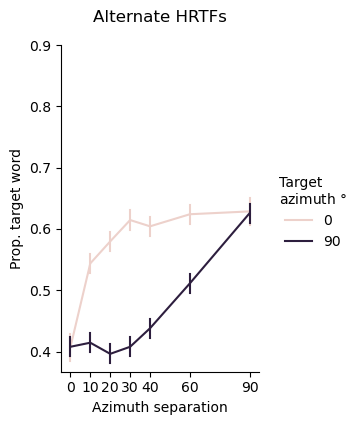

In [20]:
to_plot = results.copy()
# to_plot = to_plot[to_plot.group != '50% co-located GB v08 4M']
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)

to_plot = to_plot[to_plot.dist_azim_delta.le(90)]
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            height=4, aspect=0.75,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0.4, .91, 0.1));
# set xtick labels 
# g.set_xticklabels([0, 10, '', 30, '', 60, 90 ])
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
plt.suptitle('Alternate HRTFs', y=1.05)


In [70]:
np.linspace(0,90,4)

array([ 0., 30., 60., 90.])

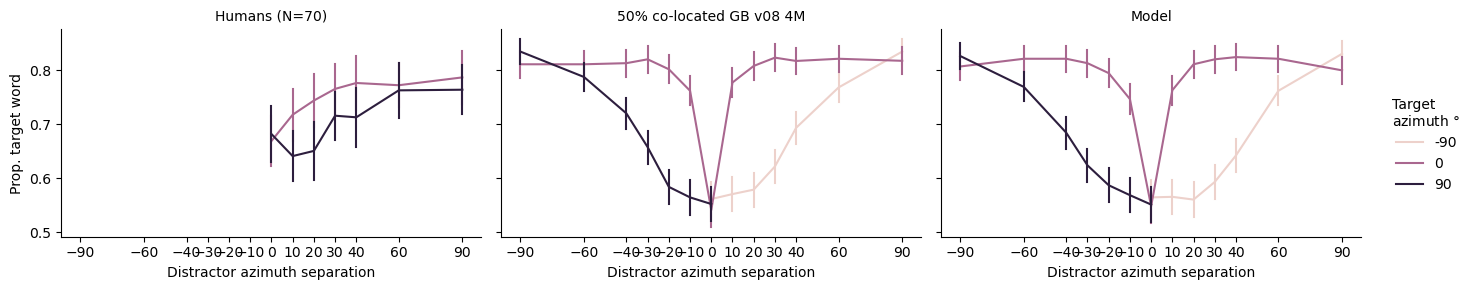

In [71]:
to_plot = combined_df.copy()
# to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            col='group',
            height=3, aspect=1.55,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique())
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
